# Trabajo Practico: 'Evidencia de Asistencia a Clase Virtual 18/03/26'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026


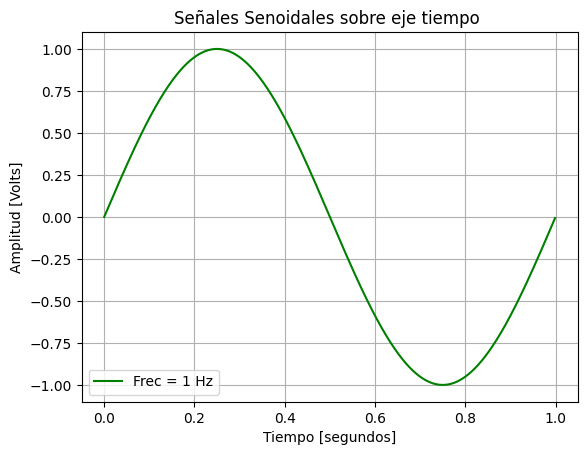

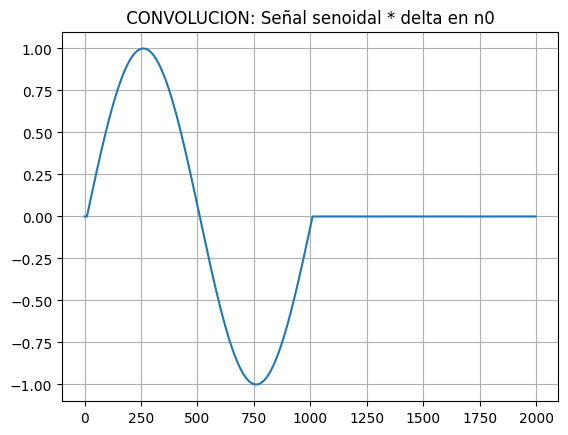

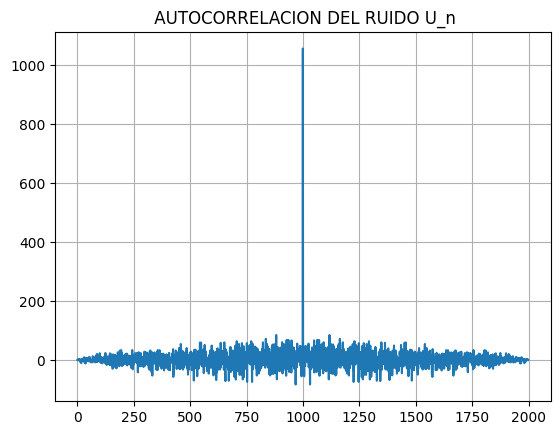

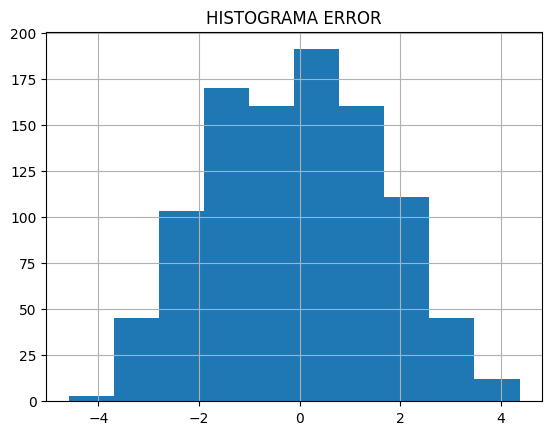

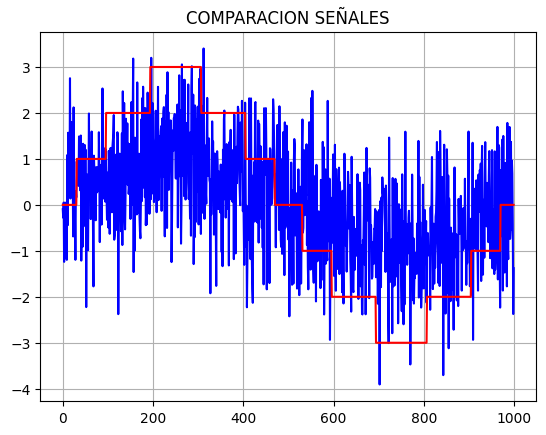

In [4]:


import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt


N = 1000    # Número de muestras
fs = N       # Frecuencia de muestreo
T = 1 / fs   # Tiempo de muestreo
df = fs / N  # Resolución espectral  
##dc = 0       #Desplazamiento vertical [V], funciona como valor medio 
##ph = 0       #FASE = Desplazamiento horizontal [rad] ya lo define en la func como 0 pq no es muy usado
## por defecto ya lo define como 0, lo mismo que Vmax y valor medio (dc)

        #cant de realizaciones 
ts = 1/fs
a0 = np.sqrt(2)
w0 = np.pi/2 
w0 = w0 * fs / (2*np.pi)
sigma = 1
mu = 0

#DEF RUIDO 
U_n =np.random.normal(mu, sigma, size=(N,1))  #señal de ruido analogico
# media: 0, desvio: raiz de ruido analogico



# Definicion funciónes seno
def func_sen( nn=N, fs=fs, Vmax=1, dc= 0, ff=1, ph= 0):
    
    tt = np.arange(0, nn / fs, T ).reshape(nn,1) ## arange ( START, STOP, STEP), T = 1/fs
    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc
    
    return tt, xx

tt1, xx1 = func_sen(ff=1, fs=fs)



# GRAFICO 
# Caracteristicas del Grafico

plt.figure()
plt.grid(True)
plt.title("Señales Senoidales sobre eje tiempo ")
plt.plot(tt1, xx1, label="Frec = 1 Hz", color = 'g')

plt.legend(loc = 'lower left')
plt.xlabel("Tiempo [segundos]")
plt.ylabel("Amplitud [Volts]")
plt.grid(True)
plt.show()

#%%
n0 = 10
dd = np.zeros(N).reshape(N, 1)
dd[n0] = 1
yy = sig.convolve(xx1,dd)

plt.figure()
plt.grid(True)
plt.title(" CONVOLUCION: Señal senoidal * delta en n0 ")
plt.plot(yy)

yy1= sig.convolve(U_n, np.flip(U_n))
plt.figure()
plt.grid(True)
plt.title(" AUTOCORRELACION DEL RUIDO U_n")
plt.plot(yy1)


#%%

B = 3   #BITS
Vfs = 3 # VOLTS
qq = Vfs / 2**B  #pasos de cuantizacion 

xxq = np.round(xx1 / qq )  ##cuantificada y codificada !
xx1 = xx1 + U_n
ee = xxq - xx1
plt.figure()
plt.grid(True)
plt.title("HISTOGRAMA ERROR" )
plt.hist(ee)

plt.figure()
plt.title("COMPARACION SEÑALES")
plt.plot(xx1, label='señal limpia', color= 'blue')
plt.plot(xxq, label='señal cuantizada', color= 'r')
plt.grid(True)


El grafico del histograma del error, $ee$ esta mal porque esperaba una funcion uniforme entre los valores de $qq/2$ y $-qq/2$. No logre corregirlo.  